# The 2D Azimuth ("Bat Ears") Model.

Building on the SISO 1D spiking radar system

The core idea is to change Cell 2 to simulate two receivers ("ears") separated by a small distance. The echo from an off-center target will arrive at one ear slightly before the other. In Cell 3, we measure this tiny time difference (Δt) to calculate the target's angle.

### Cell 1: The Neural Transmitter (Unchanged)

This cell is identical to our original notebook. We are still transmitting a single, complex signal driven by our spike train.

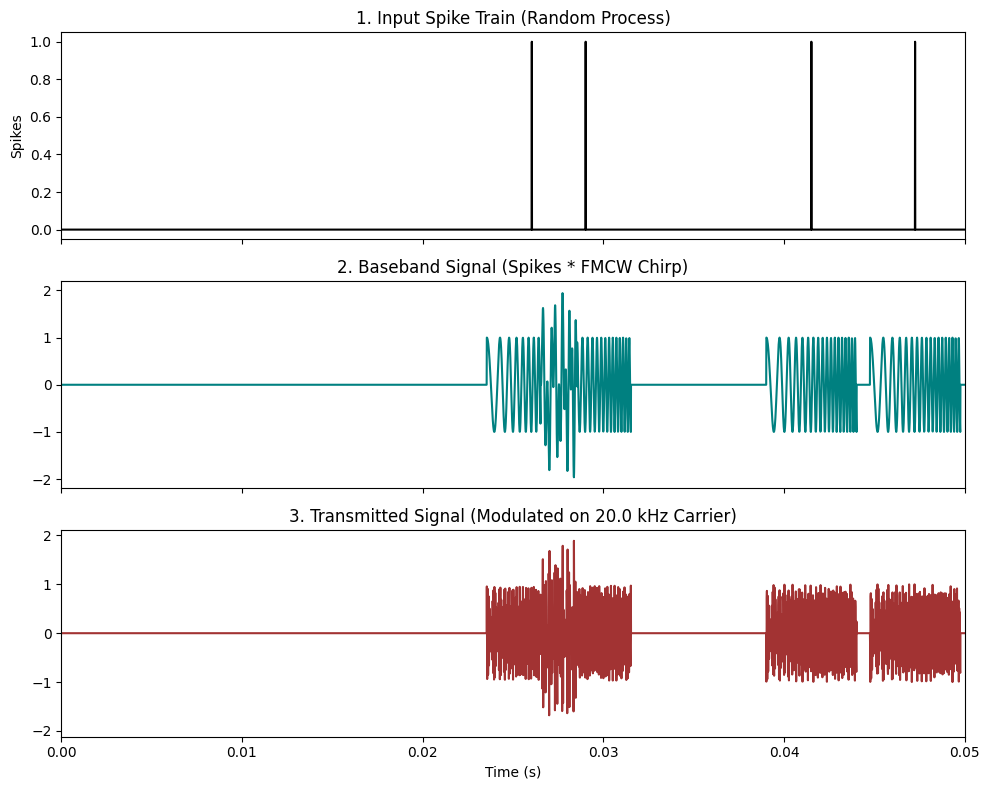

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Parameters ---
fs = 100000       # Sampling Rate (Hz)
T = 0.1           # Duration of simulation (seconds)
t = np.linspace(0, T, int(fs*T))

# Spike Generation Params
spike_prob = 0.05 # Probability of spike per millisecond

# Radar Chirp Params
chirp_duration = 0.005 # 5ms chirp
bw = 5000              # Bandwidth of chirp (5 kHz)
f_start = 1000         # Start Freq (1 kHz)

# Carrier Params
f_carrier = 20000      # 20 kHz Carrier

# --- 1. Generate Input Spike Train ---
np.random.seed(42) # Fixed seed
raw_spikes = (np.random.rand(len(t)) < (spike_prob * 1000 / fs)).astype(float)

# --- 2. Generate the Base Waveform (FMCW Chirp) ---
t_chirp = np.linspace(0, chirp_duration, int(fs*chirp_duration))
chirp_template = signal.chirp(t_chirp, f0=f_start, f1=f_start+bw, t1=chirp_duration, method='linear')

# --- 3. The Sifting Theorem (Convolution) ---
baseband_signal = signal.convolve(raw_spikes, chirp_template, mode='same')

# --- 4. Modulation (Put on Carrier) ---
tx_signal = baseband_signal * np.cos(2 * np.pi * f_carrier * t)

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, raw_spikes, color='black')
ax[0].set_title("1. Input Spike Train (Random Process)")
ax[0].set_ylabel("Spikes")
ax[0].set_xlim(0, 0.05) # Zoom in

ax[1].plot(t, baseband_signal, color='teal')
ax[1].set_title("2. Baseband Signal (Spikes * FMCW Chirp)")

ax[2].plot(t, tx_signal, color='darkred', alpha=0.8)
ax[2].set_title(f"3. Transmitted Signal (Modulated on {f_carrier/1000} kHz Carrier)")
ax[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### Cell 2: The 2D Channel & Dual Receivers

Concept: An off-center target creates two different path lengths.

This is where the new physics is implemented. We define a 2D environment. We use trigonometry (Law of Cosines) to find the exact distance from the target to the "Left Ear" and "Right Ear". This creates two separate received signals.

--- 2D Physics ---
Target: 5.0m at 30.0 deg
Path (Left): 5.0507m | Path (Right): 4.9508m
ToF (Left): 29.45ms | ToF (Right): 28.87ms
Time Difference: 0.5830 ms


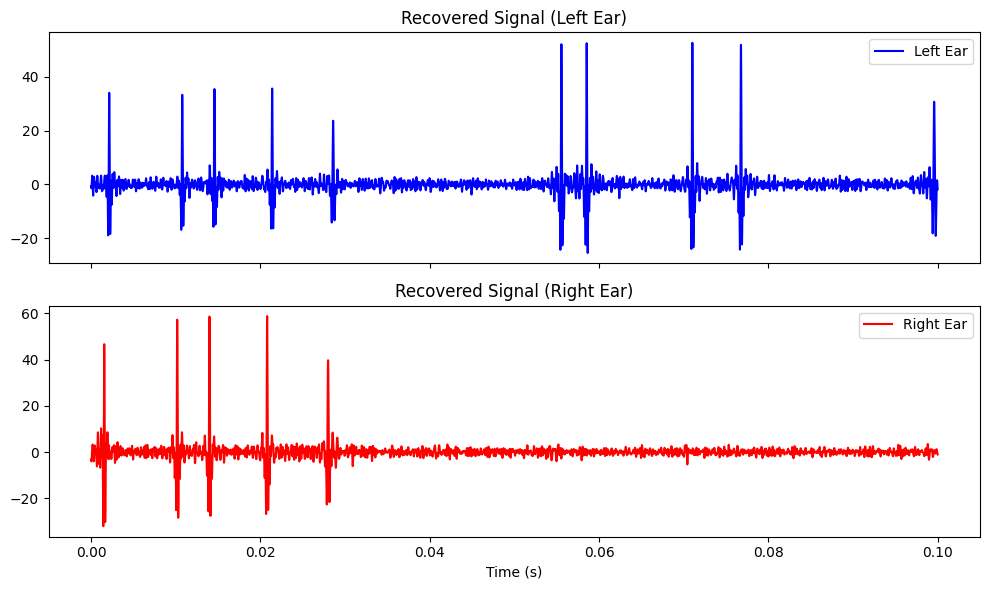

In [2]:
# --- 1. Environment & Physics Setup ---
c = 343  # Speed of sound (m/s)
receiver_separation = 0.2 # 20cm separation between "ears"
d = receiver_separation / 2 # Distance from center

# --- Target Position (Change these!) ---
target_range = 5.0  # 5 meters away
target_angle_deg = 30.0 # 30 degrees to the right
target_angle_rad = np.deg2rad(target_angle_deg)

# --- 2. Calculate Path Lengths (Law of Cosines) ---
# We have a triangle: [Target, Center, Left Ear] and [Target, Center, Right Ear]
# Path to Left Ear
dist_left = np.sqrt(target_range**2 + d**2 - 2 * target_range * d * np.cos(np.pi/2 + target_angle_rad))
# Path to Right Ear
dist_right = np.sqrt(target_range**2 + d**2 - 2 * target_range * d * np.cos(np.pi/2 - target_angle_rad))

# Calculate individual times-of-flight
tof_left = (dist_left * 2) / c  # *2 for round trip
tof_right = (dist_right * 2) / c
time_difference_ms = (tof_left - tof_right) * 1000

print(f"--- 2D Physics ---")
print(f"Target: {target_range}m at {target_angle_deg} deg")
print(f"Path (Left): {dist_left:.4f}m | Path (Right): {dist_right:.4f}m")
print(f"ToF (Left): {tof_left*1000:.2f}ms | ToF (Right): {tof_right*1000:.2f}ms")
print(f"Time Difference: {np.abs(time_difference_ms):.4f} ms")

# --- 3. Simulate Two Received Signals ---
delay_samples_left = int(tof_left * fs)
delay_samples_right = int(tof_right * fs)

rx_signal_left = np.roll(tx_signal, delay_samples_left) * 0.45 + np.random.normal(0, 0.1, len(t))
rx_signal_right = np.roll(tx_signal, delay_samples_right) * 0.5 + np.random.normal(0, 0.1, len(t))

# --- 4. Dual Receiver (Demodulate & Matched Filter) ---
def process_channel(rx_signal):
    # Demodulate
    demod_raw = rx_signal * np.cos(2 * np.pi * f_carrier * t)
    sos = signal.butter(10, f_carrier, 'low', fs=fs, output='sos')
    rx_baseband = signal.sosfilt(sos, demod_raw)
    
    # Matched Filter (Reverse System)
    matched_filter = chirp_template[::-1]
    recovered_signal = signal.convolve(rx_baseband, matched_filter, mode='same')
    return recovered_signal

recovered_left = process_channel(rx_signal_left)
recovered_right = process_channel(rx_signal_right)

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(t, recovered_left, color='blue', label="Left Ear")
ax[0].set_title("Recovered Signal (Left Ear)")
ax[0].legend()

ax[1].plot(t, recovered_right, color='red', label="Right Ear")
ax[1].set_title("Recovered Signal (Right Ear)")
ax[1].set_xlabel("Time (s)")
ax[1].legend()

plt.tight_layout()
plt.show()

### Cell 3: The Analysis (Distance & Angle)

Concept: Use Δt to find Angle θ.

This is the "bat brain" part.

We run cross-correlation for both ears to find their individual delays.

We average these delays to get a robust distance measurement.

We subtract these delays to get the tiny time difference, Δt.

We use the equation θ=arcsin( 
d⋅2
c⋅Δt
​	
 ) to solve for the angle. (The d*2 is receiver_separation).

--- RESULTS ---
ACTUAL Distance: 5.00 m |    CALCULATED: -3.57 m
ACTUAL Angle:    30.00 deg |  CALCULATED: 90.00 deg


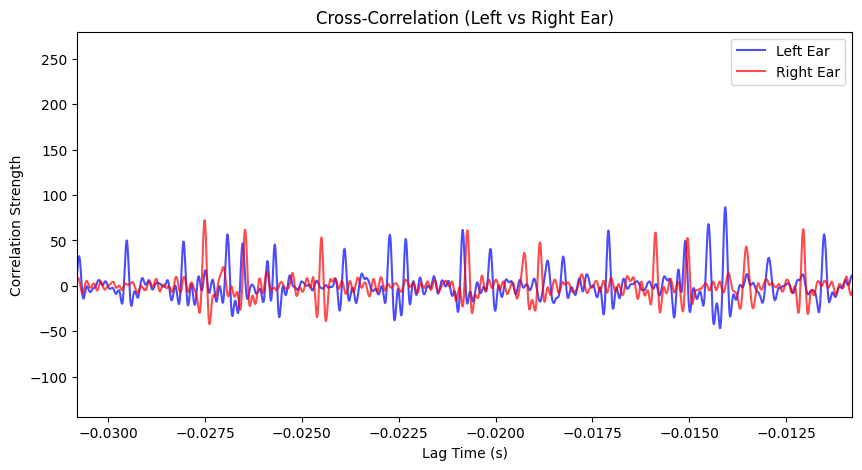

In [3]:
# --- 1. Dual Cross-Correlation ---
correlation_left = signal.correlate(recovered_left, raw_spikes, mode='full')
correlation_right = signal.correlate(recovered_right, raw_spikes, mode='full')
lags = signal.correlation_lags(len(recovered_left), len(raw_spikes), mode='full')

# --- 2. Find Peaks ---
peak_lag_left = lags[np.argmax(correlation_left)]
peak_lag_right = lags[np.argmax(correlation_right)]

# Convert lags from samples to time
delay_time_left = peak_lag_left / fs
delay_time_right = peak_lag_right / fs

# --- 3. Calculate Results ---

# --- A) DISTANCE ---
# Average the two delays for a robust distance measurement
avg_delay_time = (delay_time_left + delay_time_right) / 2
calculated_distance = (c * avg_delay_time) / 2

# --- B) ANGLE ---
# Calculate the Inter-aural Time Difference (ITD)
delta_t = delay_time_left - delay_time_right

# Calculate Angle (arcsin of time difference * speed / separation)
# We must protect against rounding errors where delta_t is > 1.0
asin_arg = (c * delta_t) / receiver_separation
asin_arg = np.clip(asin_arg, -1.0, 1.0) # Clip to [-1, 1] range
calculated_angle_rad = np.arcsin(asin_arg)
calculated_angle_deg = np.rad2deg(calculated_angle_rad)


print(f"--- RESULTS ---")
print(f"ACTUAL Distance: {target_range:.2f} m |    CALCULATED: {calculated_distance:.2f} m")
print(f"ACTUAL Angle:    {target_angle_deg:.2f} deg |  CALCULATED: {calculated_angle_deg:.2f} deg")

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

lag_time = lags / fs
ax.plot(lag_time, correlation_left, color='blue', alpha=0.7, label="Left Ear")
ax.plot(lag_time, correlation_right, color='red', alpha=0.7, label="Right Ear")

ax.axvline(delay_time_left, color='blue', linestyle='--')
ax.axvline(delay_time_right, color='red', linestyle='--')

ax.set_title("Cross-Correlation (Left vs Right Ear)")
ax.set_xlabel("Lag Time (s)")
ax.set_ylabel("Correlation Strength")
ax.legend()
ax.set_xlim(avg_delay_time - 0.01, avg_delay_time + 0.01) # Zoom in on peaks
plt.show()